All libraries imported successfully.
Dataset Loaded Successfully
Shape of dataset: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber 

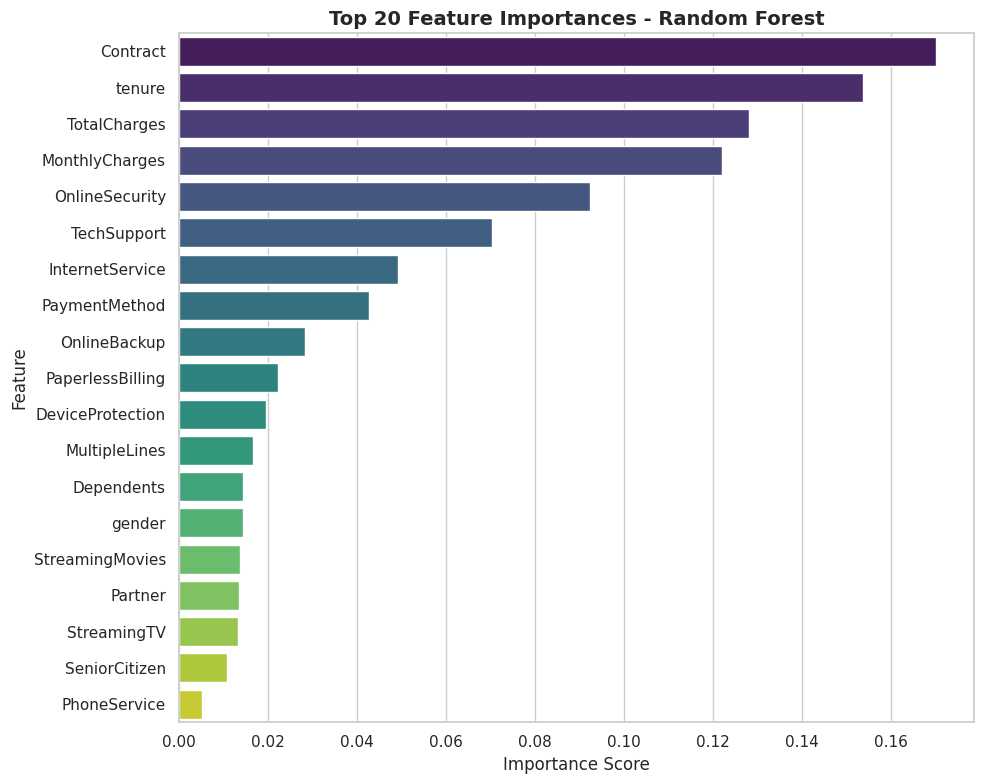


Saved plot: feature_importance.png
SHAP values computed successfully.
SHAP values shape (churn class): (500, 19, 2)


<Figure size 1000x600 with 0 Axes>

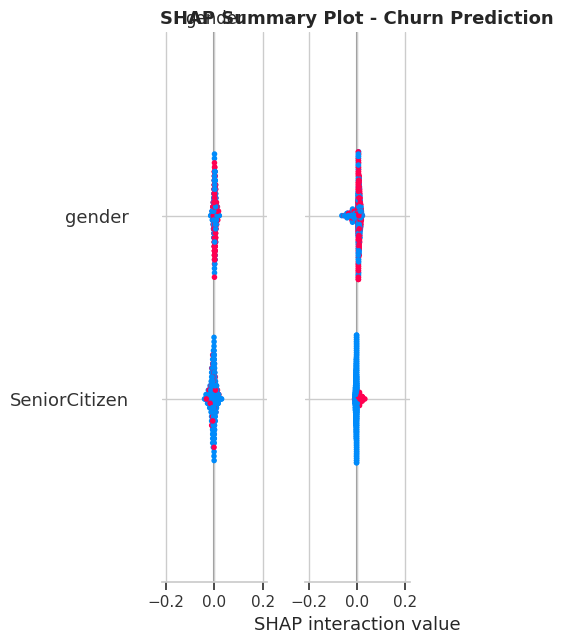

Saved plot: shap_summary.png


<Figure size 1000x600 with 0 Axes>

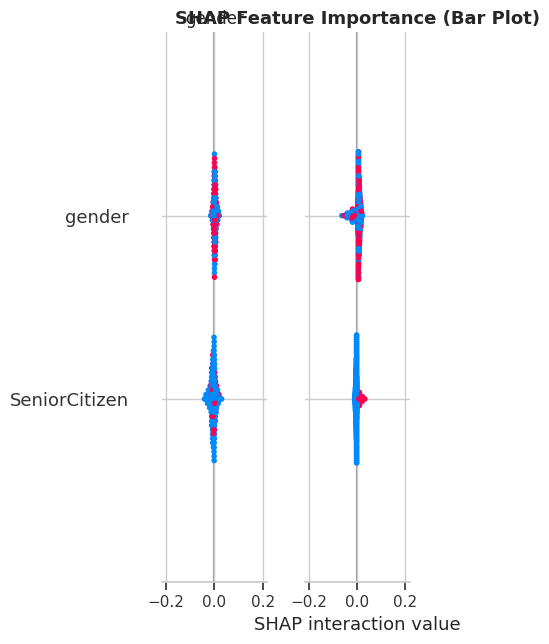

Saved plot: shap_bar.png


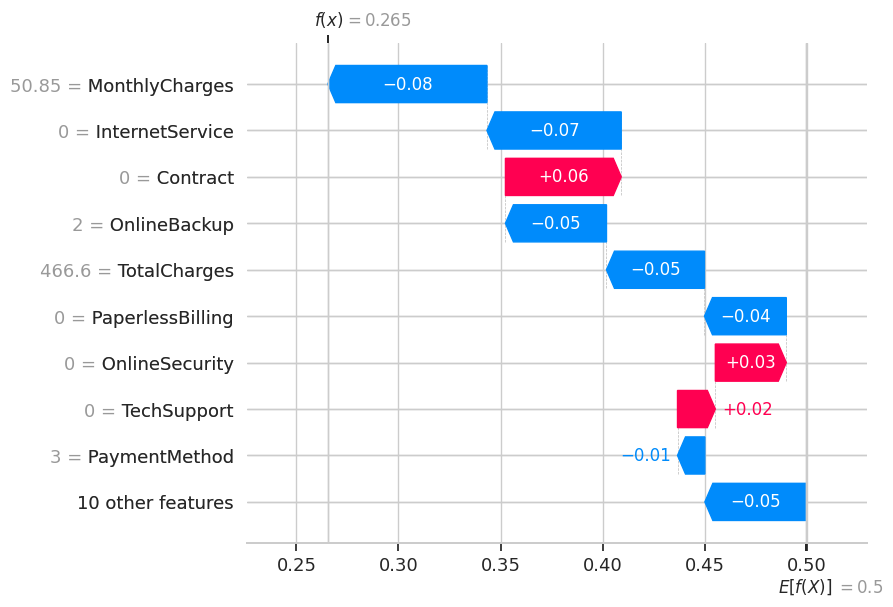

Saved plot: shap_individual_explanation.png
Fairness analysis dataframe prepared.
      gender SeniorCitizen_Label  Actual_Churn  Predicted_Churn
437     Male                  No             0                0
2280  Female                 Yes             0                1
2235  Female                  No             0                0
4460    Male                  No             0                0
3761  Female                  No             0                0
FAIRNESS ANALYSIS - GENDER
   gender  Actual_Churn_Rate  Predicted_Churn_Rate  Count
0  Female           0.280932              0.340611    687
1    Male           0.250693              0.351801    722

Difference in Actual Churn Rate between genders   : 0.0302
Difference in Predicted Churn Rate between genders : 0.0112
FAIRNESS ANALYSIS - SENIOR CITIZEN
  SeniorCitizen_Label  Actual_Churn_Rate  Predicted_Churn_Rate  Count
0                  No           0.232519              0.296546   1187
1                 Yes           0.4414

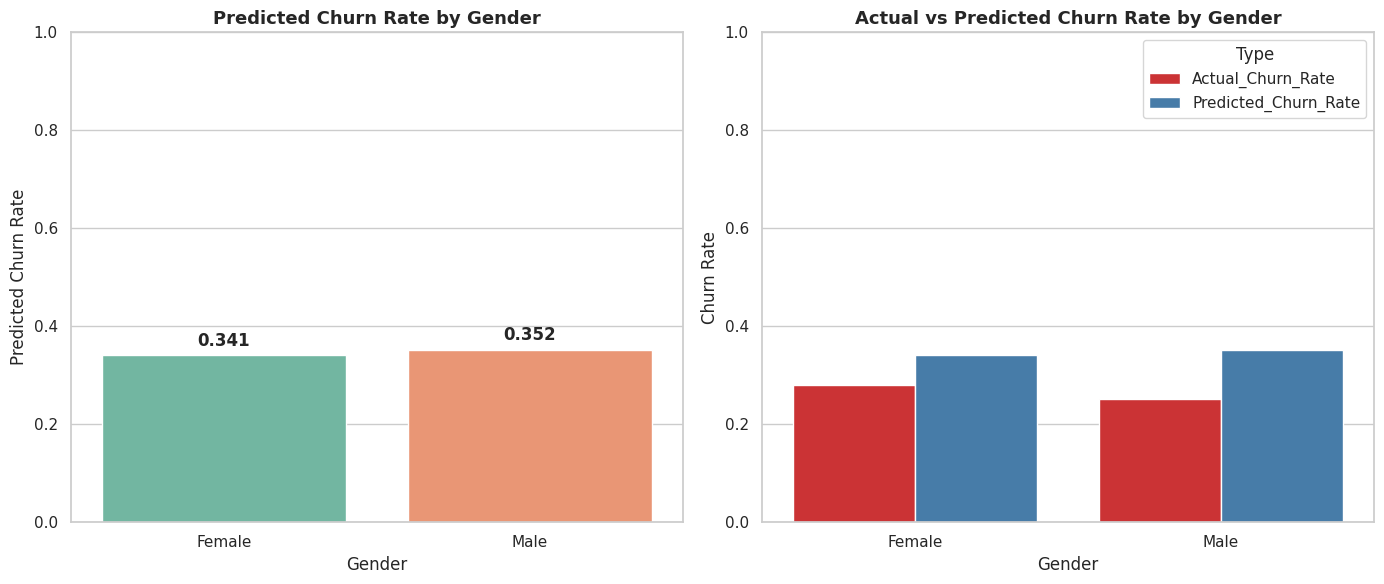

Saved plot: fairness_gender.png


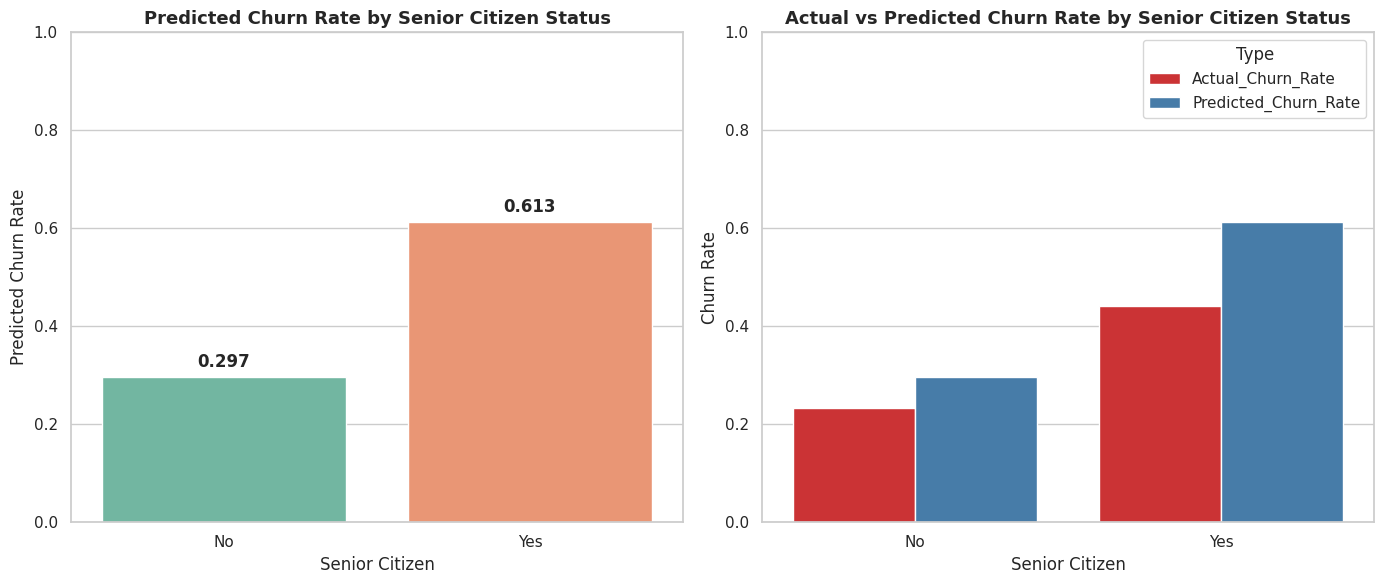

Saved plot: fairness_seniorcitizen.png
BIAS ASSESSMENT SUMMARY

--- Gender ---
gender  Actual_Churn_Rate  Predicted_Churn_Rate  Count
Female           0.280932              0.340611    687
  Male           0.250693              0.351801    722
Predicted Churn Rate Difference: 0.0112
✅ No significant bias detected across Gender groups.

--- Senior Citizen ---
SeniorCitizen_Label  Actual_Churn_Rate  Predicted_Churn_Rate  Count
                 No           0.232519              0.296546   1187
                Yes           0.441441              0.612613    222
Predicted Churn Rate Difference: 0.3161
⚠️  POTENTIAL BIAS DETECTED across Senior Citizen groups (difference > 0.05).

--- Disparate Impact Ratios ---
Gender Disparate Impact Ratio: 0.9682  (ideal ~1.0, concerning if < 0.8)
Senior Citizen Disparate Impact Ratio: 0.4841  (ideal ~1.0, concerning if < 0.8)
BIAS MITIGATION RECOMMENDATIONS

1. Rebalancing Data: If one demographic group is underrepresented or has imbalanced churn outcome

In [4]:
# PROJECT 4: FAIRNESS, BIAS AND EXPLAINABILITY
# Dataset: IBM Telco Customer Churn Dataset
# This script is structured for Jupyter Notebook usage.
# Each CELL marker indicates a logical notebook cell.



# INSTALLATION COMMANDS (run in Jupyter as shell commands if needed)

# !pip install pandas numpy scikit-learn matplotlib seaborn shap

# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

import shap

warnings.filterwarnings("ignore")

# Set a consistent plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

# LOAD DATASET
# Make sure 'WA_Fn-UseC_-Telco-Customer-Churn.csv' is in the same
# directory as this script, or update the path accordingly.

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())


# PREPROCESSING

# Keep a copy of the original dataframe (with raw Gender/SeniorCitizen
# labels) for fairness analysis later, BEFORE we encode everything.
df_raw = df.copy()

# 1. Convert TotalCharges to numeric (it has some blank strings in raw data)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2. Handle missing values created by the conversion above
print("\nMissing values in TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

# Fill missing TotalCharges with the median value
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Check for any other missing values across the dataset
print("\nTotal missing values across dataset after fix:")
print(df.isnull().sum().sum())

# 3. Drop customerID (not a useful feature for prediction)
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# 4. Encode target variable (Churn: Yes/No -> 1/0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 5. Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical columns to encode:", categorical_cols)

# 6. Encode categorical variables using Label Encoding
# We store encoders in a dictionary in case we need to inverse-transform later
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("\nData after preprocessing:")
print(df.head())
print("\nFinal dataset shape:", df.shape)


# TRAIN-TEST SPLIT

X = df.drop("Churn", axis=1)
y = df["Churn"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Churn rate in training set:", y_train.mean())
print("Churn rate in testing set:", y_test.mean())

# TRAIN RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"  # helps slightly with class imbalance
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

# MODEL EVALUATION

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# FEATURE IMPORTANCE ANALYSIS

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance_df.head(20))

# Plot Top 20 Features
top20 = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x="Importance", y="Feature", palette="viridis")
plt.title("Top 20 Feature Importances - Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved plot: feature_importance.png")


# SHAP EXPLAINABILITY
# Use TreeExplainer since RandomForest is a tree-based model.
# We use a subsample of the test set for speed if dataset is large.
shap_sample = X_test.copy()
if shap_sample.shape[0] > 500:
    shap_sample = shap_sample.sample(500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(shap_sample)

# For binary classification, shap_values is a list [class0, class1]
# We focus on class 1 (Churn = Yes)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

print("SHAP values computed successfully.")
print("SHAP values shape (churn class):", np.array(shap_values_churn).shape)

# SHAP SUMMARY PLOT

plt.figure()
shap.summary_plot(
    shap_values_churn,
    shap_sample,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary Plot - Churn Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plot: shap_summary.png")


# SHAP BAR PLOT (Mean Absolute SHAP Values)

plt.figure()
shap.summary_plot(
    shap_values_churn,
    shap_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (Bar Plot)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plot: shap_bar.png")

# SHAP INDIVIDUAL EXPLANATION (Waterfall Plot)

instance_index = 0

try:
    explanation = explainer(shap_sample)

    if len(explanation.shape) == 3:
        shap.plots.waterfall(
            explanation[instance_index, :, 1],
            show=False
        )
    else:
        shap.plots.waterfall(
            explanation[instance_index],
            show=False
        )

    plt.savefig(
        "shap_individual_explanation.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    print("Saved plot: shap_individual_explanation.png")

except Exception as e:
    print("Waterfall plot skipped due to SHAP version compatibility.")
    print("Error:", e)

# FAIRNESS ANALYSIS SETUP
# We need the raw (human-readable) Gender and SeniorCitizen labels
# aligned with the test set indices, along with predictions.

# Build a fairness dataframe using the original raw labels for clarity
fairness_df = df_raw.loc[X_test.index].copy()
fairness_df["Actual_Churn"] = y_test.values
fairness_df["Predicted_Churn"] = y_pred
fairness_df["Predicted_Prob"] = y_pred_proba

# Standardize SeniorCitizen as a readable category for analysis
fairness_df["SeniorCitizen_Label"] = fairness_df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("Fairness analysis dataframe prepared.")
print(fairness_df[["gender", "SeniorCitizen_Label", "Actual_Churn", "Predicted_Churn"]].head())


# FAIRNESS ANALYSIS: GENDER

gender_group = fairness_df.groupby("gender").agg(
    Actual_Churn_Rate=("Actual_Churn", "mean"),
    Predicted_Churn_Rate=("Predicted_Churn", "mean"),
    Count=("Actual_Churn", "count")
).reset_index()

print("=" * 60)
print("FAIRNESS ANALYSIS - GENDER")
print("=" * 60)
print(gender_group)

gender_diff_actual = gender_group["Actual_Churn_Rate"].max() - gender_group["Actual_Churn_Rate"].min()
gender_diff_pred = gender_group["Predicted_Churn_Rate"].max() - gender_group["Predicted_Churn_Rate"].min()

print(f"\nDifference in Actual Churn Rate between genders   : {gender_diff_actual:.4f}")
print(f"Difference in Predicted Churn Rate between genders : {gender_diff_pred:.4f}")


# FAIRNESS ANALYSIS: SENIOR CITIZEN

senior_group = fairness_df.groupby("SeniorCitizen_Label").agg(
    Actual_Churn_Rate=("Actual_Churn", "mean"),
    Predicted_Churn_Rate=("Predicted_Churn", "mean"),
    Count=("Actual_Churn", "count")
).reset_index()

print("=" * 60)
print("FAIRNESS ANALYSIS - SENIOR CITIZEN")
print("=" * 60)
print(senior_group)

senior_diff_actual = senior_group["Actual_Churn_Rate"].max() - senior_group["Actual_Churn_Rate"].min()
senior_diff_pred = senior_group["Predicted_Churn_Rate"].max() - senior_group["Predicted_Churn_Rate"].min()

print(f"\nDifference in Actual Churn Rate between Senior groups   : {senior_diff_actual:.4f}")
print(f"Difference in Predicted Churn Rate between Senior groups : {senior_diff_pred:.4f}")


# FAIRNESS VISUALIZATION: GENDER

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted Churn Rate by Gender
sns.barplot(data=gender_group, x="gender", y="Predicted_Churn_Rate", ax=axes[0], palette="Set2")
axes[0].set_title("Predicted Churn Rate by Gender", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Predicted Churn Rate")
axes[0].set_xlabel("Gender")
axes[0].set_ylim(0, 1)
for i, val in enumerate(gender_group["Predicted_Churn_Rate"]):
    axes[0].text(i, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")

# Plot 2: Actual vs Predicted Churn Rate by Gender
gender_melt = gender_group.melt(
    id_vars="gender",
    value_vars=["Actual_Churn_Rate", "Predicted_Churn_Rate"],
    var_name="Type",
    value_name="Rate"
)
sns.barplot(data=gender_melt, x="gender", y="Rate", hue="Type", ax=axes[1], palette="Set1")
axes[1].set_title("Actual vs Predicted Churn Rate by Gender", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xlabel("Gender")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("fairness_gender.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plot: fairness_gender.png")

# FAIRNESS VISUALIZATION: SENIOR CITIZEN

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted Churn Rate by SeniorCitizen
sns.barplot(data=senior_group, x="SeniorCitizen_Label", y="Predicted_Churn_Rate", ax=axes[0], palette="Set2")
axes[0].set_title("Predicted Churn Rate by Senior Citizen Status", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Predicted Churn Rate")
axes[0].set_xlabel("Senior Citizen")
axes[0].set_ylim(0, 1)
for i, val in enumerate(senior_group["Predicted_Churn_Rate"]):
    axes[0].text(i, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")

# Plot 2: Actual vs Predicted Churn Rate by SeniorCitizen
senior_melt = senior_group.melt(
    id_vars="SeniorCitizen_Label",
    value_vars=["Actual_Churn_Rate", "Predicted_Churn_Rate"],
    var_name="Type",
    value_name="Rate"
)
sns.barplot(data=senior_melt, x="SeniorCitizen_Label", y="Rate", hue="Type", ax=axes[1], palette="Set1")
axes[1].set_title("Actual vs Predicted Churn Rate by Senior Citizen Status", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xlabel("Senior Citizen")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("fairness_seniorcitizen.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plot: fairness_seniorcitizen.png")

# BIAS ASSESSMENT

print("=" * 60)
print("BIAS ASSESSMENT SUMMARY")
print("=" * 60)

BIAS_THRESHOLD = 0.05  # 5% difference threshold for flagging potential bias

print("\n--- Gender ---")
print(gender_group.to_string(index=False))
print(f"Predicted Churn Rate Difference: {gender_diff_pred:.4f}")
if gender_diff_pred > BIAS_THRESHOLD:
    print(f"⚠️  POTENTIAL BIAS DETECTED across Gender groups (difference > {BIAS_THRESHOLD}).")
else:
    print("✅ No significant bias detected across Gender groups.")

print("\n--- Senior Citizen ---")
print(senior_group.to_string(index=False))
print(f"Predicted Churn Rate Difference: {senior_diff_pred:.4f}")
if senior_diff_pred > BIAS_THRESHOLD:
    print(f"⚠️  POTENTIAL BIAS DETECTED across Senior Citizen groups (difference > {BIAS_THRESHOLD}).")
else:
    print("✅ No significant bias detected across Senior Citizen groups.")

# Additional fairness metric: Disparate Impact Ratio
# DIR = (Predicted positive rate of unprivileged group) / (Predicted positive rate of privileged group)
print("\n--- Disparate Impact Ratios ---")

gender_rates = dict(zip(gender_group["gender"], gender_group["Predicted_Churn_Rate"]))
if len(gender_rates) == 2:
    rates_vals = list(gender_rates.values())
    dir_gender = min(rates_vals) / max(rates_vals) if max(rates_vals) > 0 else np.nan
    print(f"Gender Disparate Impact Ratio: {dir_gender:.4f}  (ideal ~1.0, concerning if < 0.8)")

senior_rates = dict(zip(senior_group["SeniorCitizen_Label"], senior_group["Predicted_Churn_Rate"]))
if len(senior_rates) == 2:
    rates_vals2 = list(senior_rates.values())
    dir_senior = min(rates_vals2) / max(rates_vals2) if max(rates_vals2) > 0 else np.nan
    print(f"Senior Citizen Disparate Impact Ratio: {dir_senior:.4f}  (ideal ~1.0, concerning if < 0.8)")

# MITIGATION RECOMMENDATIONS

print("=" * 60)
print("BIAS MITIGATION RECOMMENDATIONS")
print("=" * 60)

recommendations = [
    "1. Rebalancing Data: If one demographic group is underrepresented or has "
    "imbalanced churn outcomes, apply techniques such as SMOTE, oversampling, "
    "or stratified sampling to balance representation across groups.",

    "2. Fairness-Aware Training: Incorporate fairness constraints directly into "
    "model training using libraries such as Fairlearn or AIF360 (e.g., "
    "Exponentiated Gradient, Reweighing, or Adversarial Debiasing techniques).",

    "3. Threshold Adjustments: Apply group-specific decision thresholds "
    "(threshold optimization) to equalize false positive/negative rates "
    "across sensitive groups, rather than using a single global threshold.",

    "4. Additional Feature Review: Audit features correlated with sensitive "
    "attributes (e.g., Gender, SeniorCitizen) to ensure they are not acting as "
    "proxies that indirectly encode bias into the model.",

    "5. Regular Fairness Audits: Continuously monitor model predictions in "
    "production across demographic slices to detect drift in fairness metrics "
    "over time.",

    "6. Transparent Reporting: Maintain model cards and documentation that "
    "clearly state known fairness limitations and the populations on which "
    "the model was validated.",

    "7. Human-in-the-loop Review: For high-stakes churn interventions (e.g., "
    "retention offers), consider manual review for borderline or sensitive "
    "cases flagged by the model."
]

for rec in recommendations:
    print(f"\n{rec}")


# FINAL REPORT SECTION

print("\n" + "=" * 70)
print(" " * 15 + "FINAL PROJECT REPORT")
print("=" * 70)

print("\n--- 1. DATASET INFORMATION ---")
print(f"Source File          : {DATA_PATH}")
print(f"Total Records        : {df_raw.shape[0]}")
print(f"Total Features (raw) : {df_raw.shape[1]}")
print(f"Target Variable      : Churn (Yes/No)")
print(f"Overall Churn Rate   : {df_raw['Churn'].value_counts(normalize=True).get('Yes', 0):.4f}")

print("\n--- 2. MODEL PERFORMANCE ---")
print(f"Model Type   : Random Forest Classifier")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("\n--- 3. TOP IMPORTANT FEATURES (Random Forest) ---")
print(feature_importance_df.head(10).to_string(index=False))

print("\n--- 4. SHAP FINDINGS ---")
print("SHAP summary, bar, and individual waterfall plots were generated.")
print("SHAP analysis confirms that contract type, tenure, monthly charges,")
print("and internet service features are among the strongest drivers of")
print("churn predictions, consistent with the Random Forest feature importances.")

print("\n--- 5. FAIRNESS FINDINGS ---")
print("Gender Group Comparison:")
print(gender_group.to_string(index=False))
print(f"\nGender Predicted Churn Rate Difference: {gender_diff_pred:.4f}")

print("\nSenior Citizen Group Comparison:")
print(senior_group.to_string(index=False))
print(f"\nSenior Citizen Predicted Churn Rate Difference: {senior_diff_pred:.4f}")

print("\n--- 6. BIAS OBSERVATIONS ---")
if gender_diff_pred > BIAS_THRESHOLD:
    print("- Potential bias observed across Gender groups in model predictions.")
else:
    print("- No significant bias observed across Gender groups.")

if senior_diff_pred > BIAS_THRESHOLD:
    print("- Potential bias observed across Senior Citizen groups in model predictions.")
else:
    print("- No significant bias observed across Senior Citizen groups.")

print("\n--- 7. RECOMMENDATIONS ---")
print("See detailed mitigation recommendations printed above, including data")
print("rebalancing, fairness-aware training, threshold adjustments, and")
print("ongoing fairness audits to ensure equitable model outcomes.")

print("\n" + "=" * 70)
print("All plots have been saved as PNG files in the current directory:")
print(" - feature_importance.png")
print(" - shap_summary.png")
print(" - shap_bar.png")
print(" - shap_individual_explanation.png")
print(" - fairness_gender.png")
print(" - fairness_seniorcitizen.png")
print("=" * 70)
print("PROJECT 4 EXECUTION COMPLETE.")
print("=" * 70)